In [1]:
import json
import re
import pathlib
import multiprocessing as mp
import xarray as xr
import tqdm

import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from functools import partial

In [2]:
src_path = pathlib.Path('/gpfs/work2/0/prjs1027/swn-runs/01-feb2022/computations')
boundary_path = pathlib.Path('/gpfs/work2/0/prjs1027/guus/data/feb2022.nc')
write_dir = pathlib.Path('/gpfs/work2/0/prjs1027/tfrecords/run3')
write_dir.mkdir(exist_ok=True, parents=True)
filtered_paths = [path for path in src_path.glob('ens*') if re.search(r'\d+$', str(path))]

In [3]:
ds = xr.open_dataset(filtered_paths[0] / "202202010000/output/swan2d.nc")
boundary_ds = xr.open_dataset(boundary_path)
ds

<xarray.Dataset>
Dimensions:    (time: 25, longitude: 421, latitude: 481)
Coordinates:
  * time       (time) datetime64[ns] 2022-02-01 ... 2022-02-04
  * longitude  (longitude) float32 -12.0 -11.95 -11.9 -11.85 ... 8.9 8.95 9.0
  * latitude   (latitude) float32 48.0 48.03 48.07 48.1 ... 63.93 63.97 64.0
Data variables:
    hs         (time, latitude, longitude) float32 ...
    botl       (time, latitude, longitude) float32 ...
    hswe       (time, latitude, longitude) float32 ...
    tmm10      (time, latitude, longitude) float32 ...
    tps        (time, latitude, longitude) float32 ...
    theta0     (time, latitude, longitude) float32 ...
    spread     (time, latitude, longitude) float32 ...
    ssh        (time, latitude, longitude) float32 ...
    xcur       (time, latitude, longitude) float32 ...
    ycur       (time, latitude, longitude) float32 ...
    xwnd       (time, latitude, longitude) float32 ...
    ywnd       (time, latitude, longitude) float32 ...
Attributes:
    Conventions:             CF-1.5
    History:                 Created with agioncmd version 1.5
    Directional_convention:  nautical
    project:                 SWAN-EPS
    run:                     028

In [7]:
ens_datasets = list(filtered_paths[0].glob('*/*/swan2d.nc'))

In [9]:
xr.concat(xr.open_dataset())

<xarray.Dataset>
Dimensions:    (time: 25, longitude: 421, latitude: 481)
Coordinates:
  * time       (time) datetime64[ns] 2022-02-03 ... 2022-02-06
  * longitude  (longitude) float32 -12.0 -11.95 -11.9 -11.85 ... 8.9 8.95 9.0
  * latitude   (latitude) float32 48.0 48.03 48.07 48.1 ... 63.93 63.97 64.0
Data variables:
    hs         (time, latitude, longitude) float32 ...
    botl       (time, latitude, longitude) float32 ...
    hswe       (time, latitude, longitude) float32 ...
    tmm10      (time, latitude, longitude) float32 ...
    tps        (time, latitude, longitude) float32 ...
    theta0     (time, latitude, longitude) float32 ...
    spread     (time, latitude, longitude) float32 ...
    ssh        (time, latitude, longitude) float32 ...
    xcur       (time, latitude, longitude) float32 ...
    ycur       (time, latitude, longitude) float32 ...
    xwnd       (time, latitude, longitude) float32 ...
    ywnd       (time, latitude, longitude) float32 ...
Attributes:
    Conventions:             CF-1.5
    History:                 Created with agioncmd version 1.5
    Directional_convention:  nautical
    project:                 SWAN-EPS
    run:                     028

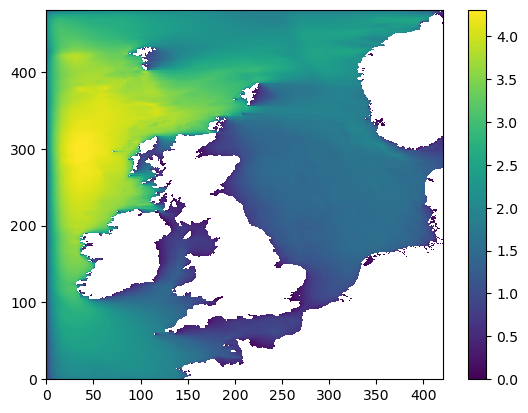

In [4]:
fig, ax = plt.subplots()
# ax.imshow(ds.tmm10[0, ...].values)
im = ax.pcolormesh(ds.hs[18, ...].values)
plt.colorbar(im)

In [5]:
output_variables = ["hs", "theta0_x", "theta0_y", "tmm10", "tps", "hswe"]
input_variables = ["xwnd", "ywnd", "ssh", "xcur", "ycur"]
boundary_variables = ["hs", "hswe", "tmm10"]
conversion_dict = {"hs": "Hm0", "hswe": "HE10", "tmm10": "Tmm10"}

In [6]:
def gather_input(path, boundary_ds, variables, boundary_variables):
    input_fields = {}
    input_fields = {var: [] for var in variables}
    boundary_fields = {var: [] for var in boundary_variables}
    for _ in tqdm.tqdm(list(path.glob('*'))):
        try:
            ds = xr.open_dataset(_ / "output/swan2d.nc")
        except:
            # print(f"{_ / 'output/swan2d.nc'} does not exist, skipping")
            continue

        for var in variables:
            if var == "theta0_x":
                data = np.cos(np.deg2rad(ds["theta0"].values))
            elif var == "theta0_y":
                data = np.sin(np.deg2rad(ds["theta0"].values))
            else:
                data = ds[var].values

            shapes = data.shape
            combined_fields = np.empty(((shapes[0] - 1) // 2, shapes[1], shapes[2], 2))
            for t in range(2, shapes[0], 2):
                combined_fields[(t - 1) // 2, ..., 0] = data[t - 1, ...]
                combined_fields[(t - 1) // 2, ..., 1] = data[t, ...]

                if var in list(boundary_fields.keys()):
                    boundary_field = boundary_ds[conversion_dict[var]].sel(time=ds.time[t]).values
                    boundary_field = boundary_field.reshape((1, boundary_field.shape[0]))
                    boundary_fields[var].append(boundary_field.astype(np.float32))
            input_fields[var].append(combined_fields.astype(np.float32))

    # Concatenate all the arrays for each variable
    for var in variables:
        input_fields[var] = np.concatenate(input_fields[var], axis=0)
        if var in list(boundary_fields.keys()):
            boundary_fields[var] = np.concatenate(boundary_fields[var], axis=0)
                # try:
                #     previous_field = ds[var][t - 1, ...].values.reshape(1, shapes[1], shapes[2], 1)
                #     current_field = ds[var][t, ...].values.reshape(1, shapes[1], shapes[2], 1)
                #     input_field = np.concatenate([previous_field, current_field], axis=-1)
                #     input_fields[var] = np.concatenate([input_fields[var], input_field], axis=0)
                # except:
                #     previous_field = ds[var][t - 1, ...].values.reshape(1, shapes[1], shapes[2], 1)
                #     current_field = ds[var][t, ...].values.reshape(1, shapes[1], shapes[2], 1)
                #     input_field = np.concatenate([previous_field, current_field], axis=-1)
                #     input_fields[var] = input_field

    print(f"Done with {path}")
    return input_fields, boundary_fields
        # print(_ / "output/swan2d.nc")

In [7]:
def get_files(data_path):
    files = tf.io.gfile.glob(data_path + "/" + "*.tfrecords")
    return files


def get_dataset(files):
    """return a tfrecord dataset with all tfrecord files"""
    dataset = tf.data.TFRecordDataset(files)
    dataset = dataset.map(tf_parse)
    return dataset


def _bytes_feature(value):
    """Returns a bytes_list from a string / byte."""
    if isinstance(value, type(tf.constant(0))):
        # BytesList won't unpack a string from an EagerTensor.
        value = value.numpy()
    return tf.train.Feature(bytes_list=tf.train.BytesList(value=[value]))


def _float_feature(value):
    """Returns a float_list from a float / double."""
    return tf.train.Feature(float_list=tf.train.FloatList(value=[value]))


def _int64_feature(value):
    """Returns an int64_list from a bool / enum / int / uint."""
    return tf.train.Feature(int64_list=tf.train.Int64List(value=[value]))


def serialize_array(array):
    array = tf.io.serialize_tensor(array)
    return array


def parse_combined_data(variables):
    # define the dictionary -- the structure -- of our single example
    var = list(variables.keys())[0]
    data = {
        "height": _int64_feature(variables[var].shape[0]),
        "width": _int64_feature(variables[var].shape[1]),
        "depth": _int64_feature(variables[var].shape[2]),
    }

    # define dictionary for each mode
    for var in variables.keys():
        data[var] = _bytes_feature(serialize_array(variables[var]))

    out = tf.train.Example(features=tf.train.Features(feature=data))

    return out


def write_data(variables, filename, max_files, out_dir):
    """Writes the data to multiple tfrecord files each containing max_files examples"""
    try:
        filename = filename.stem
    except:
        pass
    var = list(variables.keys())[0]
    splits = (len(variables[var]) // max_files) + 1
    if len(variables[var]) % max_files == 0:
        splits -= 1

    print(
        f"\nUsing {splits} shard(s) for {len(variables[var])} files,\
            with up to {max_files} samples per shard"
    )

    file_count = 0

    for i in tqdm.tqdm(range(splits)):
        if i == splits - 1 and len(variables[var]) % max_files != 0:
            current_shard_name = "{}{}_{}_{}_{}.tfrecords".format(
                out_dir, i + 1, splits, filename, len(variables[var]) % max_files
            )
        else:
            current_shard_name = "{}{}_{}_{}_{}.tfrecords".format(
                out_dir, i + 1, splits, filename, max_files
            )

        options = tf.io.TFRecordOptions(compression_type='GZIP')
        writer = tf.io.TFRecordWriter(current_shard_name)

        current_shard_count = 0
        while current_shard_count < max_files:
            index = i * max_files + current_shard_count
            if index == len(variables[var]):
                break

            current_variables = {}
            for key in variables.keys():
                current_variables[key] = variables[key][index]
                
            out = parse_combined_data(current_variables)

            writer.write(out.SerializeToString())
            current_shard_count += 1
            file_count += 1

        writer.close()

    print(f"\nWrote {file_count} elements to TFRecord")
    return file_count


def get_dataset_large(
    tfr_dir=str(write_dir) + "train_data/", pattern: str = "*train_data.tfrecords"
):
    """Loads the tfrecord files and returns a tfrecord dataset"""
    files = glob.glob(tfr_dir + pattern, recursive=False)

    dataset = tf.data.TFRecordDataset(files)

    dataset = dataset.map(tf_parse)

    return dataset

def tf_parse(eg):
    """parse an example (or batch of examples, not quite sure...)"""

    # here we re-specify our format
    # you can also infer the format from the data using tf.train.Example.FromString
    # but that did not work
    vars = variable_fields
    parse_dict =         {
            "height": tf.io.FixedLenFeature([], tf.int64),
            "width": tf.io.FixedLenFeature([], tf.int64),
            "depth": tf.io.FixedLenFeature([], tf.int64),
        }

    for var in vars:
        parse_dict[var] = tf.io.FixedLenFeature([], tf.string)
    
    example = tf.io.parse_example(
        eg[tf.newaxis],
        parse_dict,
    )
    hs = tf.io.parse_tensor(example["hs"][0], out_type="float32")
    hs_bnd = tf.io.parse_tensor(example["hs_bnd"][0], out_type="float32")
    # inputs = tf.io.parse_tensor(example["inputs"][0], out_type="float64")
    # outputs = tf.io.parse_tensor(example["outputs"][0], out_type="float64")
    return hs, hs_bnd

In [8]:
output_variables = ["hs", "theta0_x", "theta0_y", "tmm10", "tps", "hswe"]
input_variables = ["xwnd", "ywnd", "ssh", "xcur", "ycur"]
variable_fields, boundary_fields = gather_input(filtered_paths[0], boundary_ds, input_variables + output_variables, boundary_variables)

100%|██████████| 27/27 [00:17<00:00,  1.52it/s]


Done with /gpfs/work2/0/prjs1027/swn-runs/01-feb2022/computations/ens28


In [9]:
for var in boundary_variables:
    variable_fields[f"{var}_bnd"] = boundary_fields[var]

In [33]:
write_data(
    variable_fields,
    max_files=100,
    filename=filtered_paths[0].stem,
    out_dir=str(write_dir) + "/",
)


Using 3 shard(s) for 228 files,            with up to 100 samples per shard


100%|██████████| 3/3 [00:04<00:00,  1.53s/it]


Wrote 228 elements to TFRecord


228

In [10]:
partial_gather_input = partial(gather_input, boundary_ds=boundary_ds, variables=input_variables + output_variables, boundary_variables=boundary_variables)
partial_write_data = partial(write_data, max_files=100, out_dir=str(write_dir) + "/")
for paths in filtered_paths:
    variable_fields, boundary_fields = partial_gather_input(paths)
    for var in boundary_variables:
        variable_fields[f"{var}_bnd"] = boundary_fields[var]
    partial_write_data(variables=variable_fields, filename=paths)

100%|██████████| 27/27 [00:13<00:00,  2.00it/s]


Done with /gpfs/work2/0/prjs1027/swn-runs/01-feb2022/computations/ens28

Using 3 shard(s) for 228 files,            with up to 100 samples per shard


  0%|          | 0/3 [00:00<?, ?it/s]2024-06-25 08:32:16.574667: E tensorflow/compiler/xla/stream_executor/cuda/cuda_driver.cc:267] failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected
2024-06-25 08:32:16.574796: I tensorflow/compiler/xla/stream_executor/cuda/cuda_diagnostics.cc:156] kernel driver does not appear to be running on this host (tcn470.local.snellius.surf.nl): /proc/driver/nvidia/version does not exist
100%|██████████| 3/3 [00:04<00:00,  1.53s/it]



Wrote 228 elements to TFRecord


100%|██████████| 27/27 [00:18<00:00,  1.48it/s]


...


Wrote 228 elements to TFRecord


100%|██████████| 27/27 [00:17<00:00,  1.51it/s]


Done with /gpfs/work2/0/prjs1027/swn-runs/01-feb2022/computations/ens34

Using 3 shard(s) for 228 files,            with up to 100 samples per shard


100%|██████████| 3/3 [00:04<00:00,  1.40s/it]


Wrote 228 elements to TFRecord


tf.Tensor(
[ 8.099463   8.239433   8.342115   8.455119   8.502033   8.600983
  8.618585   8.464139   8.192619   7.8923717  7.5074506 10.3419285
 10.785477  10.080206   9.380303   8.110587   7.051001   6.4836407
  5.8958464  5.8004527  5.4630117  4.5546494], shape=(22,), dtype=float32)
tf.Tensor(
[7.778004  7.759838  7.7989974 7.504734  7.3042526 7.1657853 7.158836
 7.121287  6.9070563 6.7423344 6.536789  8.16728   9.509487  9.317458
 8.780133  8.124011  7.136156  6.335048  5.804292  5.7465477 5.4563346
 4.65425  ], shape=(22,), dtype=float32)
tf.Tensor(
[7.749007  7.6323547 7.378729  7.1638427 6.9904485 6.914121  6.744663
 6.670438  6.6534424 6.6938834 6.6661944 7.8644304 9.117564  9.048926
 8.4103155 7.6996465 6.998183  6.2623434 5.686088  5.6790795 5.40884
 4.5723433], shape=(22,), dtype=float32)
tf.Tensor(
[ 6.714695   6.6352825  6.488405   6.4651427  6.496195   6.5172687
  6.588146   6.665582   6.7016325  6.4911027  6.1221375  7.2481318
  8.617595  10.286611   8.458168   7.599032  

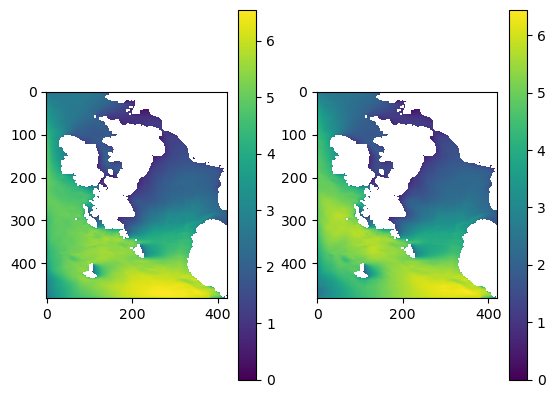

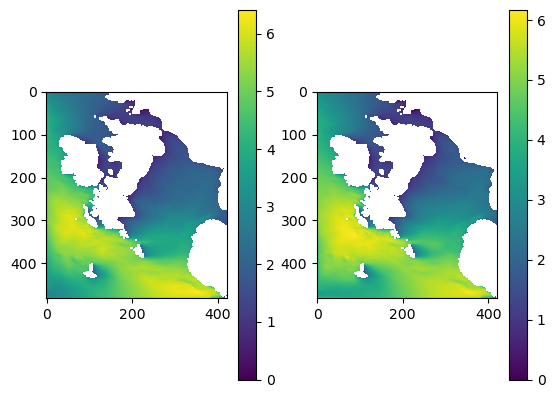

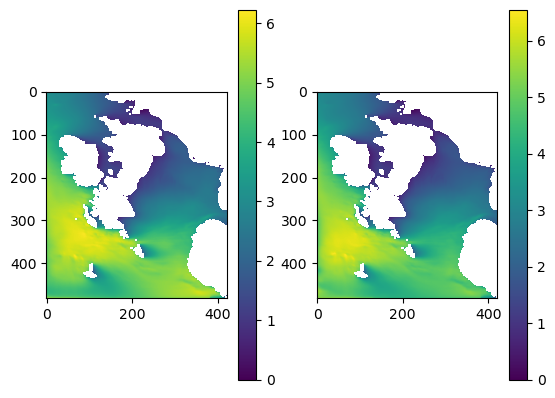

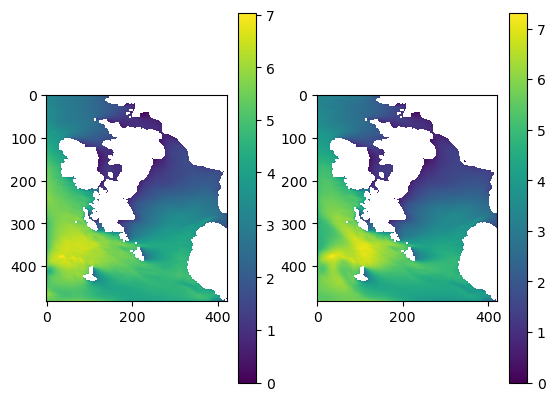

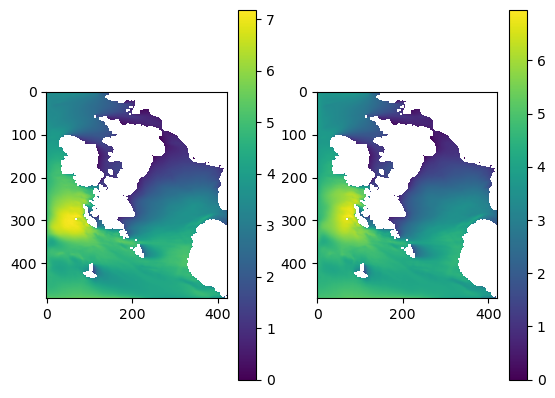

In [11]:
files = get_files(str(write_dir))
dataset = get_dataset(files)
for hs, hs_bnd in dataset.take(5):
    fig, ax = plt.subplots(ncols = 2)
    im1 = ax[0].imshow(hs[..., 0], vmin=0)
    im2 = ax[1].imshow(hs[..., -1], vmin=0)
    plt.colorbar(im1)
    plt.colorbar(im2)
    print(hs_bnd)
    # print(hs)

In [8]:
def compute_min_max(path):
    all_datasets = []
    
    for _ in tqdm.tqdm(list(path.glob('*'))):
        try:
            ds = xr.open_dataset(_ / "output/swan2d.nc")
            all_datasets.append(ds)
        except:
            continue

    combined_ds = xr.concat(all_datasets, dim="time")
    min_max_values = {}
    for var in combined_ds.variables:
        min_value = combined_ds[var].min().values
        max_value = combined_ds[var].max().values
        min_max_values[var] = np.array([min_value, max_value])
    return min_max_values

In [9]:
min_max_values = compute_min_max(filtered_paths[0])
min_max_values

100%|██████████| 27/27 [00:04<00:00,  5.78it/s]


{'time': array(['2022-02-01T00:00:00.000000000', '2022-02-21T03:00:00.000000000'],
       dtype='datetime64[ns]'),
 'longitude': array([-12.,   9.]),
 'latitude': array([48., 64.]),
 'hs': array([ 0.        , 15.94820976]),
 'botl': array([ -93.95513153, 4276.97021484]),
 'hswe': array([ 0.        , 14.69618797]),
 'tmm10': array([5.34057617e-03, 5.00000000e+01]),
 'tps': array([ 1.74718475, 33.33308029]),
 'theta0': array([  0., 360.]),
 'spread': array([ 0.        , 81.02664185]),
 'ssh': array([-6.06097603,  6.80898476]),
 'xcur': array([-18.75545502,  14.77584171]),
 'ycur': array([-18.75545502,  14.77584171]),
 'xwnd': array([-24.93362236,  29.99359131]),
 'ywnd': array([-30.05462837,  22.93771172])}

In [10]:
min_max_values = {}
for paths in filtered_paths:
    min_max_values[paths.stem] = compute_min_max(paths)

100%|██████████| 27/27 [00:04<00:00,  6.62it/s]


In [11]:
min_max_values

{'ens28': {'time': array(['2022-02-01T00:00:00.000000000', '2022-02-21T03:00:00.000000000'],
        dtype='datetime64[ns]'),
  'longitude': array([-12.,   9.]),
  'latitude': array([48., 64.]),
  'hs': array([ 0.        , 15.94820976]),
  'botl': array([ -93.95513153, 4276.97021484]),
  'hswe': array([ 0.        , 14.69618797]),
  'tmm10': array([5.34057617e-03, 5.00000000e+01]),
  'tps': array([ 1.74718475, 33.33308029]),
  'theta0': array([  0., 360.]),
  'spread': array([ 0.        , 81.02664185]),
  'ssh': array([-6.06097603,  6.80898476]),
  'xcur': array([-18.75545502,  14.77584171]),
  'ycur': array([-18.75545502,  14.77584171]),
  'xwnd': array([-24.93362236,  29.99359131]),
  'ywnd': array([-30.05462837,  22.93771172])},
 'ens38': {'time': array(['2022-02-01T00:00:00.000000000', '2022-02-21T03:00:00.000000000'],
        dtype='datetime64[ns]'),
  'longitude': array([-12.,   9.]),
  'latitude': array([48., 64.]),
  'hs': array([ 0.        , 15.94820976]),
  'botl': array([ -93

In [12]:
min_max_values_detailed = {}
for ens in min_max_values.keys():
    for var in min_max_values[ens].keys():
        try:
            min_max_values_detailed[var] = np.concat([min_max_values_detailed[var], min_max_values[ens][var]])
        except:
            min_max_values_detailed[var] = min_max_values[ens][var]

In [13]:
for var in min_max_values_detailed.keys():
    min_value = min_max_values_detailed[var].min()
    max_value = min_max_values_detailed[var].max()
    min_max_values_detailed[var] = {
        "minimum": min_value,
        "maximum": max_value
    }

In [19]:
min_max_values_detailed

{'longitude': {'minimum': -12.0, 'maximum': 9.0},
 'latitude': {'minimum': 48.0, 'maximum': 64.0},
 'hs': {'minimum': 0.0, 'maximum': 15.948209762573242},
 'botl': {'minimum': -93.95513153076172, 'maximum': 4276.97021484375},
 'hswe': {'minimum': 0.0, 'maximum': 14.698476791381836},
 'tmm10': {'minimum': 0.0030517578125, 'maximum': 49.98321533203125},
 'tps': {'minimum': 1.7471847534179688, 'maximum': 33.33308029174805},
 'theta0': {'minimum': 0.0, 'maximum': 360.0},
 'spread': {'minimum': 0.0, 'maximum': 81.02664184570312},
 'ssh': {'minimum': -6.060976028442383, 'maximum': 6.808984756469727},
 'xcur': {'minimum': -18.755455017089844, 'maximum': 14.77584171295166},
 'ycur': {'minimum': -18.755455017089844, 'maximum': 14.77584171295166},
 'xwnd': {'minimum': -28.68434715270996, 'maximum': 29.12686538696289},
 'ywnd': {'minimum': -27.851192474365234, 'maximum': 24.87258529663086}}

In [23]:
df = pd.DataFrame(min_max_values_detailed)

In [39]:
ds_min_max = xr.Dataset.from_dataframe(df)
ds_min_max_dir = write_dir / "min-max-values"
ds_min_max_dir.mkdir(exist_ok=True, parents=True)
ds_min_max.to_netcdf(ds_min_max_dir / "min-max-values.nc")